2025-10-16 18:16:06.165941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760638566.426305      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760638566.494250      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1760638590.203713      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760638590.204421      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Frozen base training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1760638604.062318      84 service.cc:148] XLA service 0x7beea40022c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760638604.063512      84 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760638604.063533      84 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760638605.596928      84 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/39 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.2188 - loss: 3.2371  

I0000 00:00:1760638610.616046      84 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 44s 718ms/step - accuracy: 0.3329 - loss: 1.9819 - val_accuracy: 0.6080 - val_loss: 1.1760 - learning_rate: 0.0010
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 413ms/step - accuracy: 0.5843 - loss: 1.1805 - val_accuracy: 0.5760 - val_loss: 1.1206 - learning_rate: 0.0010
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 414ms/step - accuracy: 0.6385 - loss: 1.0489 - val_accuracy: 0.6160 - val_loss: 1.0365 - learning_rate: 0.0010
Epoch 4/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 421ms/step - accuracy: 0.6409 - loss: 1.0098 - val_accuracy: 0.6720 - val_loss: 0.9584 - learning_rate: 0.0010
Epoch 5/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 15s 394ms/step - accuracy: 0.6575 - loss: 0.9567 - val_accuracy: 0.6360 - val_loss: 0.9733 - learning_rate: 0.0010
Epoch 6/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 418ms/step - accuracy: 0.6569 - loss: 0.9408 - val_accuracy: 0.6840 - val_loss: 0.9285 - learning_rate: 0.0010
Epoch 7/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 442ms/step - accuracy: 0.6713 - loss: 0.9251 - val_

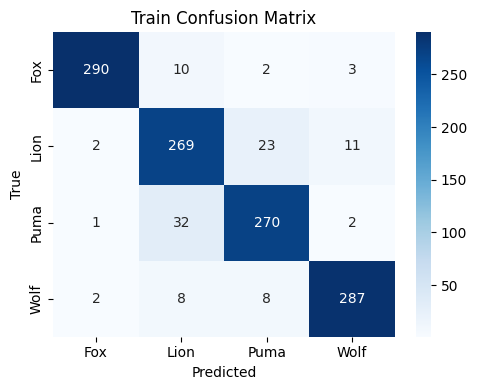


Validation Accuracy: 0.7680
              precision    recall  f1-score   support

         Fox     0.9138    0.8689    0.8908        61
        Lion     0.7500    0.6711    0.7083        76
        Puma     0.5800    0.6744    0.6237        43
        Wolf     0.7973    0.8429    0.8194        70

    accuracy                         0.7680       250
   macro avg     0.7603    0.7643    0.7605       250
weighted avg     0.7740    0.7680    0.7694       250



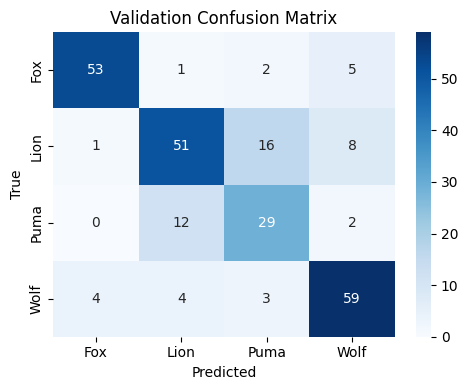


Test Accuracy: 0.8083
              precision    recall  f1-score   support

         Fox     0.9437    0.8933    0.9178        75
        Lion     0.7624    0.8021    0.7817        96
        Puma     0.6607    0.6852    0.6727        54
        Wolf     0.8471    0.8182    0.8324        88

    accuracy                         0.8083       313
   macro avg     0.8035    0.7997    0.8012       313
weighted avg     0.8121    0.8083    0.8098       313



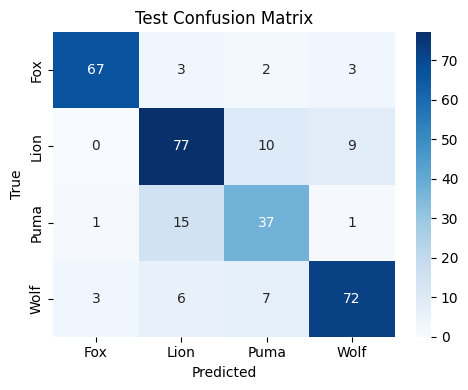

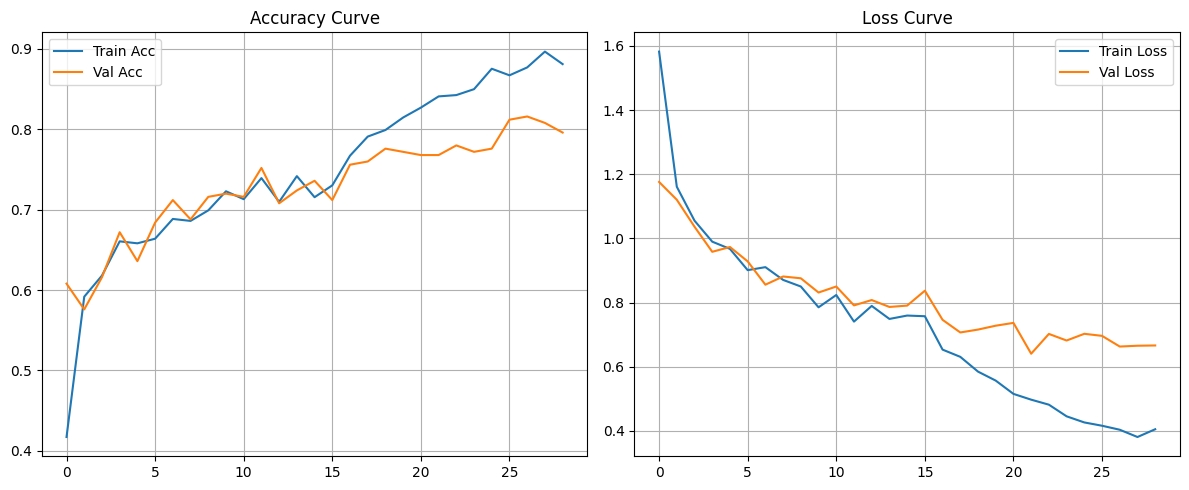


 Fit Diagnosis:
Good Fit: training and validation accuracies are close.

 Training complete and model saved.

Final Accuracies → Train: 0.9148, Val: 0.7680, Test: 0.8083


In [1]:
## Learning rate 1e-3, batch size 32, DropOut 0.6
import tensorflow as tf
from tensorflow.keras import layers, models, applications, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np, pickle, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# --------------------------- Data Loading ---------------------------
def load_data(path="/kaggle/input/animal-data-balanced/preprocessed_data_balanced"):
    X_train = np.load(f"{path}/X_train.npy")
    X_val = np.load(f"{path}/X_val.npy")
    X_test = np.load(f"{path}/X_test.npy")
    y_train = pickle.load(open(f"{path}/y_train.pkl", 'rb'))
    y_val = pickle.load(open(f"{path}/y_val.pkl", 'rb'))
    y_test = pickle.load(open(f"{path}/y_test.pkl", 'rb'))
    class_names = pickle.load(open(f"{path}/class_names.pkl", 'rb'))
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names

# --------------------------- Label Encoding ---------------------------
def encode_labels(y_train, y_val, y_test, class_names):
    le = LabelEncoder().fit(class_names)
    return le.transform(y_train), le.transform(y_val), le.transform(y_test), le

# --------------------------- Preprocessing ---------------------------
def resnet_preprocess(X):
    # Convert RGB to BGR and subtract ImageNet mean
    X = X[..., ::-1] * 255.0
    mean = [103.939, 116.779, 123.68]
    for i in range(3):
        X[..., i] -= mean[i]
    return X

# --------------------------- Data Augmentation ---------------------------
def get_datagen():
    return ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        channel_shift_range=10,
        fill_mode='nearest'
    )

# --------------------------- Model Definition ---------------------------
def build_model(num_classes, input_shape=(224,224,3)):
    base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # freeze initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.002))(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs), base

# --------------------------- Training ---------------------------
def train_model(X_train, y_train, X_val, y_val, num_classes, epochs=50, batch=32):
    model, base = build_model(num_classes)
    model.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    cbs = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint('best_model.h5', save_best_only=True)
    ]

    # Data augmentation
    train_gen = get_datagen().flow(X_train, y_train, batch_size=batch)
    
    print("Phase 1: Frozen base training...")
    hist1 = model.fit(train_gen, validation_data=(X_val, y_val),
                      epochs=min(15, epochs), callbacks=cbs, verbose=1)

    print("Phase 2: Fine-tuning last 20 layers...")
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(optimizer=Adam(5e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist2 = model.fit(train_gen, validation_data=(X_val, y_val),
                      epochs=epochs, callbacks=cbs, verbose=1)

    # Combine histories
    history = {k: hist1.history.get(k, []) + hist2.history.get(k, []) for k in set(hist1.history) | set(hist2.history)}
    return model, history

# --------------------------- Evaluation ---------------------------
def evaluate_all(model, X_train, y_train, X_val, y_val, X_test, y_test, class_names):
    sets = {'Train': (X_train, y_train), 'Validation': (X_val, y_val), 'Test': (X_test, y_test)}
    metrics = {}
    for name, (X, y) in sets.items():
        preds = np.argmax(model.predict(X, verbose=0), axis=1)
        acc = accuracy_score(y, preds)
        print(f"\n{name} Accuracy: {acc:.4f}")
        print(classification_report(y, preds, target_names=class_names, digits=4))
        metrics[name] = acc
        # Confusion Matrix
        cm = confusion_matrix(y, preds)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.show()
    return metrics

# --------------------------- Plot Training Curves ---------------------------
def plot_history(history):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history['accuracy'], label='Train Acc')
    plt.plot(history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy Curve"); plt.legend(); plt.grid(True)
    
    plt.subplot(1,2,2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title("Loss Curve"); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

    # Basic Fit Analysis
    final_train_acc = history['accuracy'][-1]
    final_val_acc = history['val_accuracy'][-1]
    gap = abs(final_train_acc - final_val_acc)
    print("\n Fit Diagnosis:")
    if final_train_acc < 0.7 and final_val_acc < 0.7:
        print("➡ Underfitting: both accuracies are low.")
    elif gap > 0.1 and final_train_acc > final_val_acc:
        print("Overfitting: training accuracy much higher than validation.")
    else:
        print("Good Fit: training and validation accuracies are close.")

# --------------------------- Main ---------------------------
def main():
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_data()
    y_train, y_val, y_test, _ = encode_labels(y_train, y_val, y_test, class_names)
    X_train, X_val, X_test = map(resnet_preprocess, [X_train, X_val, X_test])

    model, history = train_model(X_train, y_train, X_val, y_val, len(class_names))
    metrics = evaluate_all(model, X_train, y_train, X_val, y_val, X_test, y_test, class_names)
    plot_history(history)

    model.save("final_resnet_animal_model.h5")
    print("\n Training complete and model saved.")
    print(f"\nFinal Accuracies → Train: {metrics['Train']:.4f}, Val: {metrics['Validation']:.4f}, Test: {metrics['Test']:.4f}")

if __name__ == "__main__":
    main()


2025-10-16 15:31:33.833967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760628694.048017      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760628694.102772      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1760628717.282673      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Phase 1: Frozen base training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1760628735.771491      97 service.cc:148] XLA service 0x797b680028e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760628735.772320      97 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760628737.353815      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/20 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.3164 - loss: 2.0468 

I0000 00:00:1760628742.407867      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3908 - loss: 1.7131 - val_accuracy: 0.5000 - val_loss: 1.3236 - learning_rate: 5.0000e-04
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 806ms/step - accuracy: 0.5926 - loss: 1.1930 - val_accuracy: 0.6480 - val_loss: 1.1178 - learning_rate: 5.0000e-04
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 815ms/step - accuracy: 0.6443 - loss: 1.0467 - val_accuracy: 0.6520 - val_loss: 1.0325 - learning_rate: 5.0000e-04
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 798ms/step - accuracy: 0.6381 - loss: 1.0632 - val_accuracy: 0.6760 - val_loss: 0.9842 - learning_rate: 5.0000e-04
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 799ms/step - accuracy: 0.6833 - loss: 0.9539 - val_accuracy: 0.7080 - val_loss: 0.9297 - learning_rate: 5.0000e-04
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 807ms/step - accuracy: 0.6943 - loss: 0.9212 - val_accuracy: 0.7000 - val_loss: 0.9149 - learning_rate: 5.0000e-04
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 805ms/step - accuracy: 0.7526 

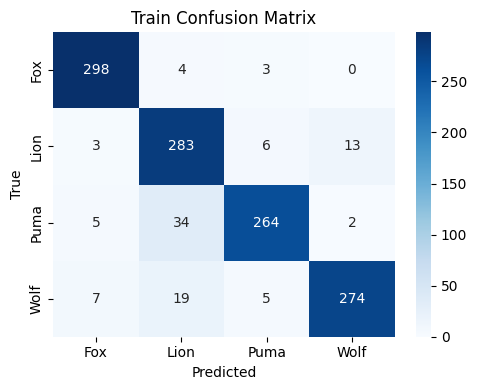


Validation Accuracy: 0.8040
              precision    recall  f1-score   support

         Fox     0.8852    0.8852    0.8852        61
        Lion     0.7561    0.8158    0.7848        76
        Puma     0.7222    0.6047    0.6582        43
        Wolf     0.8310    0.8429    0.8369        70

    accuracy                         0.8040       250
   macro avg     0.7986    0.7871    0.7913       250
weighted avg     0.8028    0.8040    0.8021       250



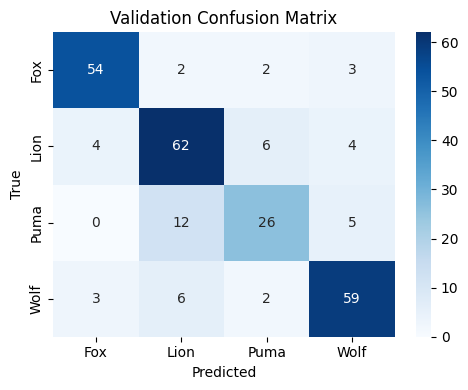


Test Accuracy: 0.8051
              precision    recall  f1-score   support

         Fox     0.8519    0.9200    0.8846        75
        Lion     0.7257    0.8542    0.7847        96
        Puma     0.7750    0.5741    0.6596        54
        Wolf     0.8861    0.7955    0.8383        88

    accuracy                         0.8051       313
   macro avg     0.8096    0.7859    0.7918       313
weighted avg     0.8095    0.8051    0.8021       313



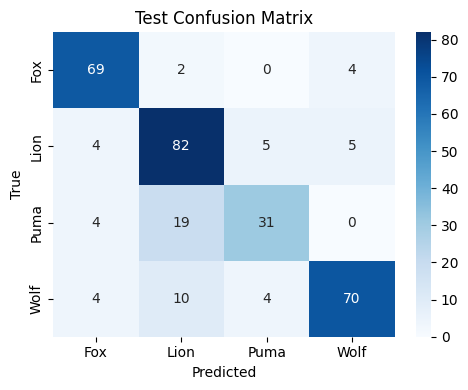

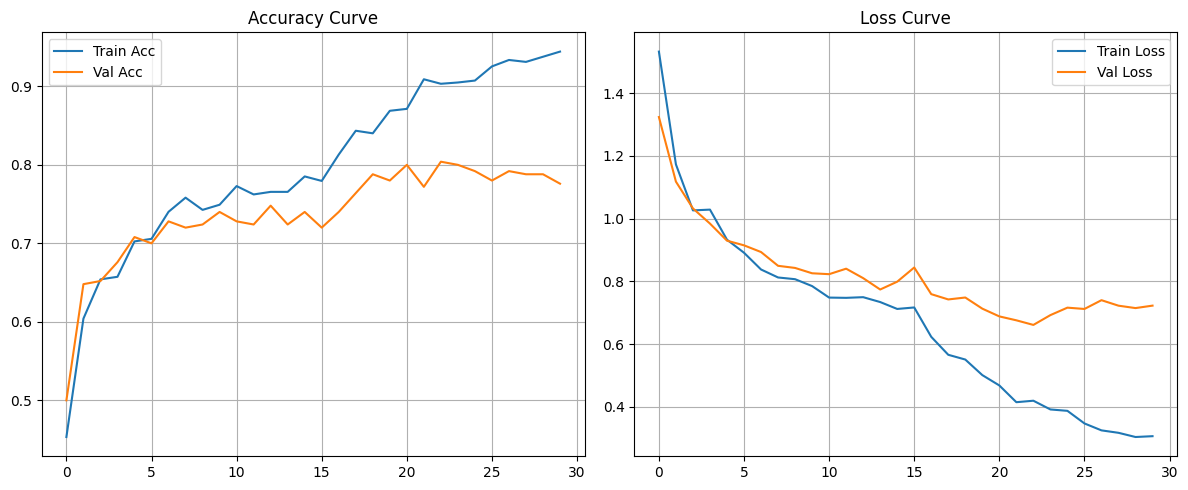


 Fit Diagnosis:
Overfitting: training accuracy much higher than validation.

 Training complete and model saved.

Final Accuracies → Train: 0.9172, Val: 0.8040, Test: 0.8051


In [1]:
# Learning rate 5e-4, batch size 64, DropOut 0.4
import tensorflow as tf
from tensorflow.keras import layers, models, applications, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np, pickle, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# --------------------------- Data Loading ---------------------------
def load_data(path="/kaggle/input/animal-data-balanced/preprocessed_data_balanced"):
    X_train = np.load(f"{path}/X_train.npy")
    X_val = np.load(f"{path}/X_val.npy")
    X_test = np.load(f"{path}/X_test.npy")
    y_train = pickle.load(open(f"{path}/y_train.pkl", 'rb'))
    y_val = pickle.load(open(f"{path}/y_val.pkl", 'rb'))
    y_test = pickle.load(open(f"{path}/y_test.pkl", 'rb'))
    class_names = pickle.load(open(f"{path}/class_names.pkl", 'rb'))
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names

# --------------------------- Label Encoding ---------------------------
def encode_labels(y_train, y_val, y_test, class_names):
    le = LabelEncoder().fit(class_names)
    return le.transform(y_train), le.transform(y_val), le.transform(y_test), le

# --------------------------- Preprocessing ---------------------------
def resnet_preprocess(X):
    # Convert RGB to BGR and subtract ImageNet mean
    X = X[..., ::-1] * 255.0
    mean = [103.939, 116.779, 123.68]
    for i in range(3):
        X[..., i] -= mean[i]
    return X

# --------------------------- Data Augmentation ---------------------------
def get_datagen():
    return ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        channel_shift_range=10,
        fill_mode='nearest'
    )

# --------------------------- Model Definition ---------------------------
def build_model(num_classes, input_shape=(224,224,3)):
    base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # freeze initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.002))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs), base

# --------------------------- Training ---------------------------
def train_model(X_train, y_train, X_val, y_val, num_classes, epochs=50, batch=64):
    model, base = build_model(num_classes)
    model.compile(optimizer=Adam(5e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    cbs = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint('best_model.h5', save_best_only=True)
    ]

    # Data augmentation
    train_gen = get_datagen().flow(X_train, y_train, batch_size=batch)
    
    print("Phase 1: Frozen base training...")
    hist1 = model.fit(train_gen, validation_data=(X_val, y_val),
                      epochs=min(15, epochs), callbacks=cbs, verbose=1)

    print("Phase 2: Fine-tuning last 20 layers...")
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(optimizer=Adam(5e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist2 = model.fit(train_gen, validation_data=(X_val, y_val),
                      epochs=epochs, callbacks=cbs, verbose=1)

    # Combine histories
    history = {k: hist1.history.get(k, []) + hist2.history.get(k, []) for k in set(hist1.history) | set(hist2.history)}
    return model, history

# --------------------------- Evaluation ---------------------------
def evaluate_all(model, X_train, y_train, X_val, y_val, X_test, y_test, class_names):
    sets = {'Train': (X_train, y_train), 'Validation': (X_val, y_val), 'Test': (X_test, y_test)}
    metrics = {}
    for name, (X, y) in sets.items():
        preds = np.argmax(model.predict(X, verbose=0), axis=1)
        acc = accuracy_score(y, preds)
        print(f"\n{name} Accuracy: {acc:.4f}")
        print(classification_report(y, preds, target_names=class_names, digits=4))
        metrics[name] = acc
        # Confusion Matrix
        cm = confusion_matrix(y, preds)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.show()
    return metrics

# --------------------------- Plot Training Curves ---------------------------
def plot_history(history):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history['accuracy'], label='Train Acc')
    plt.plot(history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy Curve"); plt.legend(); plt.grid(True)
    
    plt.subplot(1,2,2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title("Loss Curve"); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

    # Basic Fit Analysis
    final_train_acc = history['accuracy'][-1]
    final_val_acc = history['val_accuracy'][-1]
    gap = abs(final_train_acc - final_val_acc)
    print("\n Fit Diagnosis:")
    if final_train_acc < 0.7 and final_val_acc < 0.7:
        print("➡ Underfitting: both accuracies are low.")
    elif gap > 0.1 and final_train_acc > final_val_acc:
        print("Overfitting: training accuracy much higher than validation.")
    else:
        print("Good Fit: training and validation accuracies are close.")

# --------------------------- Main ---------------------------
def main():
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_data()
    y_train, y_val, y_test, _ = encode_labels(y_train, y_val, y_test, class_names)
    X_train, X_val, X_test = map(resnet_preprocess, [X_train, X_val, X_test])

    model, history = train_model(X_train, y_train, X_val, y_val, len(class_names))
    metrics = evaluate_all(model, X_train, y_train, X_val, y_val, X_test, y_test, class_names)
    plot_history(history)

    model.save("final_resnet_animal_model.h5")
    print("\n Training complete and model saved.")
    print(f"\nFinal Accuracies → Train: {metrics['Train']:.4f}, Val: {metrics['Validation']:.4f}, Test: {metrics['Test']:.4f}")

if __name__ == "__main__":
    main()


Phase 1: Frozen base training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 38s 312ms/step - accuracy: 0.2615 - loss: 1.8624 - val_accuracy: 0.5520 - val_loss: 1.2888 - learning_rate: 0.0020
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.3682 - loss: 1.3770 - val_accuracy: 0.5400 - val_loss: 1.2202 - learning_rate: 0.0020
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 199ms/step - accuracy: 0.3914 - loss: 1.3073 - val_accuracy: 0.5520 - val_loss: 1.1592 - learning_rate: 0.0020
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - accuracy: 0.3782 - loss: 1.3064 - val_accuracy: 0.5040 - val_loss: 1.1239 - learning_rate: 0.0020
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.4233 - loss: 1.2487 - val_accuracy: 0.5840 - val_loss: 1.0759 - learning_rate: 0.0020
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.4503 - loss: 1.2008 - val_accuracy: 0.5960 - val_loss: 1.0583 - learning_rate: 0.0020
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 200ms/step - accuracy: 0.4399 - loss: 1.

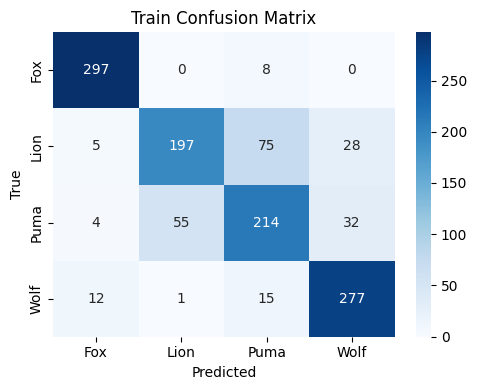


Validation Accuracy: 0.7000
              precision    recall  f1-score   support

         Fox     0.7857    0.9016    0.8397        61
        Lion     0.7069    0.5395    0.6119        76
        Puma     0.4762    0.4651    0.4706        43
        Wolf     0.7375    0.8429    0.7867        70

    accuracy                         0.7000       250
   macro avg     0.6766    0.6873    0.6772       250
weighted avg     0.6950    0.7000    0.6921       250



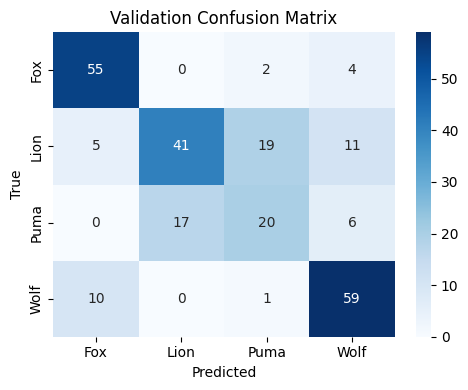


Test Accuracy: 0.7444
              precision    recall  f1-score   support

         Fox     0.8372    0.9600    0.8944        75
        Lion     0.7857    0.5729    0.6627        96
        Puma     0.5161    0.5926    0.5517        54
        Wolf     0.7789    0.8409    0.8087        88

    accuracy                         0.7444       313
   macro avg     0.7295    0.7416    0.7294       313
weighted avg     0.7496    0.7444    0.7401       313



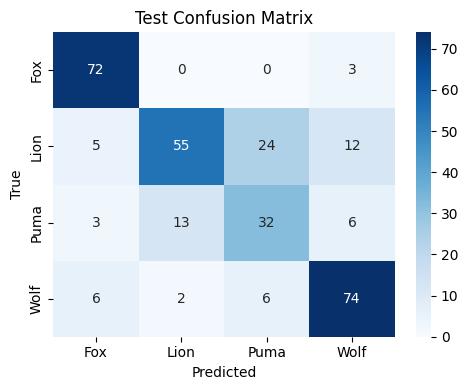

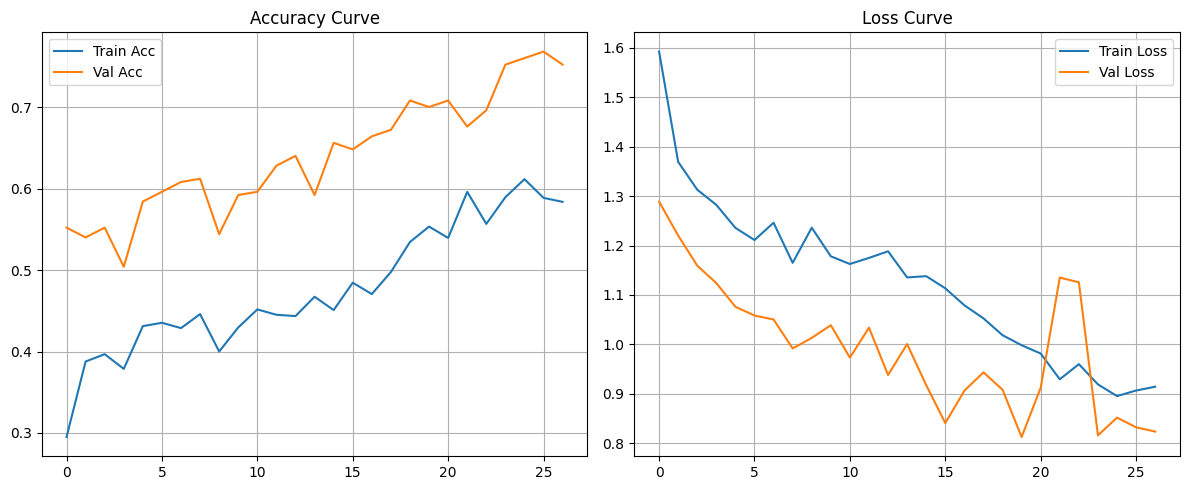


 Fit Diagnosis:
Good Fit: training and validation accuracies are close.

 Training complete and model saved.

Final Accuracies → Train: 0.8074, Val: 0.7000, Test: 0.7444


In [2]:
# Learning rate 2e-3, batch size 16, DropOut 0.7
import tensorflow as tf
from tensorflow.keras import layers, models, applications, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np, pickle, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# --------------------------- Data Loading ---------------------------
def load_data(path="/kaggle/input/animal-data-balanced/preprocessed_data_balanced"):
    X_train = np.load(f"{path}/X_train.npy")
    X_val = np.load(f"{path}/X_val.npy")
    X_test = np.load(f"{path}/X_test.npy")
    y_train = pickle.load(open(f"{path}/y_train.pkl", 'rb'))
    y_val = pickle.load(open(f"{path}/y_val.pkl", 'rb'))
    y_test = pickle.load(open(f"{path}/y_test.pkl", 'rb'))
    class_names = pickle.load(open(f"{path}/class_names.pkl", 'rb'))
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names

# --------------------------- Label Encoding ---------------------------
def encode_labels(y_train, y_val, y_test, class_names):
    le = LabelEncoder().fit(class_names)
    return le.transform(y_train), le.transform(y_val), le.transform(y_test), le

# --------------------------- Preprocessing ---------------------------
def resnet_preprocess(X):
    # Convert RGB to BGR and subtract ImageNet mean
    X = X[..., ::-1] * 255.0
    mean = [103.939, 116.779, 123.68]
    for i in range(3):
        X[..., i] -= mean[i]
    return X

# --------------------------- Data Augmentation ---------------------------
def get_datagen():
    return ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        channel_shift_range=10,
        fill_mode='nearest'
    )

# --------------------------- Model Definition ---------------------------
def build_model(num_classes, input_shape=(224,224,3)):
    base = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # freeze initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.002))(x)
    x = layers.Dropout(0.7)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs), base

# --------------------------- Training ---------------------------
def train_model(X_train, y_train, X_val, y_val, num_classes, epochs=50, batch=16):
    model, base = build_model(num_classes)
    model.compile(optimizer=Adam(2e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    cbs = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint('best_model.h5', save_best_only=True)
    ]

    # Data augmentation
    train_gen = get_datagen().flow(X_train, y_train, batch_size=batch)
    
    print("Phase 1: Frozen base training...")
    hist1 = model.fit(train_gen, validation_data=(X_val, y_val),
                      epochs=min(15, epochs), callbacks=cbs, verbose=1)

    print("Phase 2: Fine-tuning last 20 layers...")
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(optimizer=Adam(5e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist2 = model.fit(train_gen, validation_data=(X_val, y_val),
                      epochs=epochs, callbacks=cbs, verbose=1)

    # Combine histories
    history = {k: hist1.history.get(k, []) + hist2.history.get(k, []) for k in set(hist1.history) | set(hist2.history)}
    return model, history

# --------------------------- Evaluation ---------------------------
def evaluate_all(model, X_train, y_train, X_val, y_val, X_test, y_test, class_names):
    sets = {'Train': (X_train, y_train), 'Validation': (X_val, y_val), 'Test': (X_test, y_test)}
    metrics = {}
    for name, (X, y) in sets.items():
        preds = np.argmax(model.predict(X, verbose=0), axis=1)
        acc = accuracy_score(y, preds)
        print(f"\n{name} Accuracy: {acc:.4f}")
        print(classification_report(y, preds, target_names=class_names, digits=4))
        metrics[name] = acc
        # Confusion Matrix
        cm = confusion_matrix(y, preds)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.show()
    return metrics

# --------------------------- Plot Training Curves ---------------------------
def plot_history(history):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history['accuracy'], label='Train Acc')
    plt.plot(history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy Curve"); plt.legend(); plt.grid(True)
    
    plt.subplot(1,2,2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title("Loss Curve"); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

    # Basic Fit Analysis
    final_train_acc = history['accuracy'][-1]
    final_val_acc = history['val_accuracy'][-1]
    gap = abs(final_train_acc - final_val_acc)
    print("\n Fit Diagnosis:")
    if final_train_acc < 0.7 and final_val_acc < 0.7:
        print("➡ Underfitting: both accuracies are low.")
    elif gap > 0.1 and final_train_acc > final_val_acc:
        print("Overfitting: training accuracy much higher than validation.")
    else:
        print("Good Fit: training and validation accuracies are close.")

# --------------------------- Main ---------------------------
def main():
    (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_data()
    y_train, y_val, y_test, _ = encode_labels(y_train, y_val, y_test, class_names)
    X_train, X_val, X_test = map(resnet_preprocess, [X_train, X_val, X_test])

    model, history = train_model(X_train, y_train, X_val, y_val, len(class_names))
    metrics = evaluate_all(model, X_train, y_train, X_val, y_val, X_test, y_test, class_names)
    plot_history(history)

    model.save("final_resnet_animal_model.h5")
    print("\n Training complete and model saved.")
    print(f"\nFinal Accuracies → Train: {metrics['Train']:.4f}, Val: {metrics['Validation']:.4f}, Test: {metrics['Test']:.4f}")

if __name__ == "__main__":
    main()
